## 시계열분석_회귀분석실습

In [1]:
import numpy as np
import pandas as pd
import statsmodels
from statsmodels.regression import linear_model
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

In [2]:
df = pd.read_csv('air_quality_uci.csv', encoding='cp949')

In [3]:
df.head(3)

,Date,Time,CO,PT08_S1,NMHC,C6H6,PT08_S2,NOx,PT08_S3,NO2,PT08_S4,PT08_S5,T,RH,AH
0,2005-02-16,17:00:00,1.6,1083,-200,7.0,856,252,720,148,1010,975,8.2,41.8,0.4563
1,2005-02-16,18:00:00,2.2,1143,-200,9.5,960,313,641,153,1110,1136,7.4,44.5,0.4582
2,2005-02-16,19:00:00,3.4,1288,-200,15.9,1178,433,539,171,1300,1434,7.0,43.4,0.4366


In [4]:
df.shape

(1000, 15)

In [5]:
df['DateTime'] = df['Date'] + ' ' + df['Time']

In [6]:
df.head(3)

,Date,Time,CO,PT08_S1,NMHC,C6H6,PT08_S2,NOx,PT08_S3,NO2,PT08_S4,PT08_S5,T,RH,AH,DateTime
0,2005-02-16,17:00:00,1.6,1083,-200,7.0,856,252,720,148,1010,975,8.2,41.8,0.4563,2005-02-16 17:00:00
1,2005-02-16,18:00:00,2.2,1143,-200,9.5,960,313,641,153,1110,1136,7.4,44.5,0.4582,2005-02-16 18:00:00
2,2005-02-16,19:00:00,3.4,1288,-200,15.9,1178,433,539,171,1300,1434,7.0,43.4,0.4366,2005-02-16 19:00:00


In [7]:
df['DateTime'][3]

'2005-02-16 20:00:00'

In [8]:
type(df['DateTime'][3])

str

In [9]:
df['DateTimeIndex'] = pd.to_datetime(df['DateTime'])

In [10]:
df.head(3)

,Date,Time,CO,PT08_S1,NMHC,C6H6,PT08_S2,NOx,PT08_S3,NO2,PT08_S4,PT08_S5,T,RH,AH,DateTime,DateTimeIndex
0,2005-02-16,17:00:00,1.6,1083,-200,7.0,856,252,720,148,1010,975,8.2,41.8,0.4563,2005-02-16 17:00:00,2005-02-16 17:00:00
1,2005-02-16,18:00:00,2.2,1143,-200,9.5,960,313,641,153,1110,1136,7.4,44.5,0.4582,2005-02-16 18:00:00,2005-02-16 18:00:00
2,2005-02-16,19:00:00,3.4,1288,-200,15.9,1178,433,539,171,1300,1434,7.0,43.4,0.4366,2005-02-16 19:00:00,2005-02-16 19:00:00


In [11]:
# DateTimeIndex 구성 원소가 Timestamp라는 것 확인
type(df['DateTimeIndex'][3])

pandas._libs.tslibs.timestamps.Timestamp

In [12]:
df = df.set_index(keys=['DateTimeIndex'])

In [13]:
df.head(3)

,Date,Time,CO,PT08_S1,NMHC,C6H6,PT08_S2,NOx,PT08_S3,NO2,PT08_S4,PT08_S5,T,RH,AH,DateTime
DateTimeIndex,,,,,,,,,,,,,,,,
2005-02-16 17:00:00,2005-02-16,17:00:00,1.6,1083,-200,7.0,856,252,720,148,1010,975,8.2,41.8,0.4563,2005-02-16 17:00:00
2005-02-16 18:00:00,2005-02-16,18:00:00,2.2,1143,-200,9.5,960,313,641,153,1110,1136,7.4,44.5,0.4582,2005-02-16 18:00:00
2005-02-16 19:00:00,2005-02-16,19:00:00,3.4,1288,-200,15.9,1178,433,539,171,1300,1434,7.0,43.4,0.4366,2005-02-16 19:00:00


In [14]:
df.isnull().sum()

Date        0
Time        0
CO          0
PT08_S1     0
NMHC        0
C6H6        0
PT08_S2     0
NOx         0
PT08_S3     0
NO2         0
PT08_S4     0
PT08_S5     0
T           0
RH          0
AH          0
DateTime    0
dtype: int64

In [15]:
train_ratio = 0.9
n = len(df)
n_train = int(n*train_ratio)
df_train = df[:n_train]
df_test = df[n_train:]

In [16]:
n

1000

In [17]:
len(df_train)

900

In [18]:
len(df_test)

100

In [19]:
df.columns

Index(['Date', 'Time', 'CO', 'PT08_S1', 'NMHC', 'C6H6', 'PT08_S2', 'NOx',
       'PT08_S3', 'NO2', 'PT08_S4', 'PT08_S5', 'T', 'RH', 'AH', 'DateTime'],
      dtype='object')

In [20]:
features = ['T', 'AH']
target = 'PT08_S4'

X_tn = df_train[features]
y_tn = df_train[target]
X_te = df_test[features]
y_te = df_test[target]

In [21]:
## endog = 차겟
## exog = 피처

In [22]:
ols_reg = linear_model.OLS(endog=y_tn, exog=X_tn)
ols_model = ols_reg.fit()

In [23]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                PT08_S4   R-squared (uncentered):                   0.791
Model:                            OLS   Adj. R-squared (uncentered):              0.791
Method:                 Least Squares   F-statistic:                              1701.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):                   3.95e-306
Time:                        13:35:52   Log-Likelihood:                         -6942.3
No. Observations:                 900   AIC:                                  1.389e+04
Df Residuals:                     898   BIC:                                  1.390e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T             92.0877      1.590     57.911      0.000      88.967      95.209
AH           -87.9609      3.266    -26.930      0.000     -94.371     -81.550
==============================================================================
Omnibus:                       56.134   Durbin-Watson:                   0.130
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.528
Skew:                          -0.622   Prob(JB):                     5.90e-15
Kurtosis:                       3.446   Cond. No.                         2.71
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
train_predict = ols_model.predict()
# train_predict

In [25]:
test_predict = ols_model.predict(X_te)
test_predict

DateTimeIndex
2005-03-26 05:00:00    1387.973531
2005-03-26 06:00:00    1370.558743
2005-03-26 07:00:00    1371.579090
2005-03-26 08:00:00    1408.150292
2005-03-26 09:00:00    1489.956110
                          ...     
2005-03-30 04:00:00     973.827329
2005-03-30 05:00:00     854.042934
2005-03-30 06:00:00     928.926965
2005-03-30 07:00:00     902.312202
2005-03-30 08:00:00    1030.707234
Length: 100, dtype: float64

In [26]:
train_predict = pd.concat([pd.DataFrame(y_tn.index), pd.DataFrame(train_predict)], axis=1).set_index('DateTimeIndex')

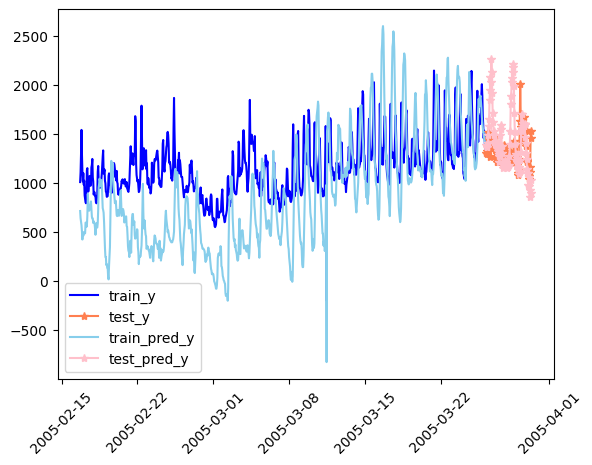

In [27]:
import matplotlib.pyplot as plt
plt.plot(y_tn, color='blue', label='train_y')
plt.plot(y_te, color='coral', label='test_y', marker='*')
plt.plot(train_predict, color='skyblue', label='train_pred_y')
plt.plot(test_predict, color='pink', label='test_pred_y', marker='*')
plt.legend()
plt.xticks(rotation=45)
plt.show()